# Generalization Benchmark Visualization

Reads benchmark config JSONs from `benchmark/results/configs_v2/` for any dataset.

| Figure | Type | Content |
|--------|------|---------|
| **2c. M1 MAE to R1** | Heatmap | M1a→M1g MAE vs R1 (K-Fold CV), per miner |
| **2d. Key Methods MAE to R1** | Heatmap | M1a/M1d/M1g vs M2–M7 MAE vs R1 |

**Usage:** Set `DATASET_KEY = "D1"` (or `"D2"`, `"D3"`, …) in the cell below, then run all.

---

In [21]:
# === Configuration: set your dataset key here ===
DATASET_KEY = "D5"   # ← Change to "D1", "D2", "D3", … "D21"

# === Imports ===
import json, glob, os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

# === Paths ===
CONFIG_DIR = os.path.join(os.getcwd(), "benchmark/results/configs_v2/")

# === Load dataset info ===
sys.path.insert(0, os.getcwd())
from benchmark.datasets import get_info

info = get_info(DATASET_KEY)
DATASET_NAME = info["name"]
DATASET_LABEL = f"{DATASET_KEY} ({DATASET_NAME})"

# === Output directory for saving results ===
OUTPUT_DIR = os.path.join(os.getcwd(), "analysis", "benchmark", DATASET_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset: {DATASET_LABEL}")
print(f"Config dir: {CONFIG_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Dataset: D5 (BPI2019)
Config dir: /home/gengtianhao/generalization_analysis/benchmark/results/configs_v2/
Output dir: /home/gengtianhao/generalization_analysis/analysis/benchmark/BPI2019


In [22]:
# === Load all config JSONs for this dataset ===
files = sorted(glob.glob(os.path.join(CONFIG_DIR, f"{DATASET_NAME}__*.json")))
print(f"Found {len(files)} config files for {DATASET_LABEL}")

records = []
for fp in files:
    basename = os.path.basename(fp)
    # Parse: {Dataset}__{Miner}__{Method}.json
    match = re.match(rf'{DATASET_NAME}__(.+)__(\w+)\.json', basename)
    if not match:
        continue
    miner = match.group(1)
    method = match.group(2)
    
    with open(fp, 'r') as f:
        data = json.load(f)
    
    method_label = data.get('method_label', method)
    
    # Extract mean value (handle varied result structures)
    results = data.get('results', {})
    mean = results.get('mean', None)
    std = results.get('std', None)
    
    # M3 special: use entropic_relevance_raw
    if mean is None and 'entropic_relevance_raw' in results:
        mean = results['entropic_relevance_raw']
    
    # M5 Trace_Filtered special: use score field
    if mean is None and 'score' in results:
        mean = results['score']
        std = 0.0
    
    # M6/M7 special: use gen_score field
    if mean is None and 'gen_score' in results:
        mean = results['gen_score']
        if 'std' not in results or results['std'] is None:
            std = 0.0
    
    records.append({
        'miner': miner,
        'method': method,
        'method_label': method_label,
        'mean': mean,
        'std': std,
        'file': basename
    })

# === Fill missing (miner, method) combinations with -1 ===
_CANONICAL_MINERS = [
    'Trace_Filtered', 'Alpha', 'Alpha+', 'Heuristics', 'Heuristics_Strict',
    'Inductive_Strict', 'Inductive_Infrequent', 'Flower',
]
_CANONICAL_METHODS = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g',
                      'M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']

present_pairs = set((r['miner'], r['method']) for r in records)
n_filled = 0
for miner in _CANONICAL_MINERS:
    for method in _CANONICAL_METHODS:
        if (miner, method) not in present_pairs:
            records.append({
                'miner': miner,
                'method': method,
                'method_label': method,
                'mean': -1.0,
                'std': -1.0,
                'file': f'__missing__{miner}__{method}'
            })
            n_filled += 1

if n_filled > 0:
    print(f"⚠ Filled {n_filled} missing (miner, method) entries with -1.0 (e.g. M5 on this dataset)")

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records ({df['method'].nunique()} methods × {df['miner'].nunique()} miners)")
print(f"\nMethods: {sorted(df['method'].unique())}")
print(f"Miners:  {sorted(df['miner'].unique())}")

Found 105 config files for D5 (BPI2019)
⚠ Filled 15 missing (miner, method) entries with -1.0 (e.g. M5 on this dataset)
Loaded 120 records (15 methods × 8 miners)

Methods: ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g', 'M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']
Miners:  ['Alpha', 'Alpha+', 'Flower', 'Heuristics', 'Heuristics_Strict', 'Inductive_Infrequent', 'Inductive_Strict', 'Trace_Filtered']


In [23]:
# === Check for missing values ===
pivot_check = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
na_count = pivot_check.isna().sum().sum()
neg1_count = (pivot_check == -1.0).sum().sum()
total_missing = int(na_count + neg1_count)
print(f"Missing values (NaN): {int(na_count)}")
print(f"Unavailable values (-1): {int(neg1_count)}")
if total_missing > 0:
    print("\nMissing/Unavailable cells:")
    for method in pivot_check.columns:
        na_miners = pivot_check.index[pivot_check[method].isna() | (pivot_check[method] == -1.0)].tolist()
        if na_miners:
            print(f"  {method}: {na_miners}")

df.head(3)

Missing values (NaN): 0
Unavailable values (-1): 15

Missing/Unavailable cells:
  M5: ['Alpha', 'Alpha+', 'Flower', 'Heuristics', 'Heuristics_Strict', 'Inductive_Infrequent', 'Inductive_Strict', 'Trace_Filtered']
  M7: ['Alpha', 'Alpha+', 'Flower', 'Heuristics', 'Heuristics_Strict', 'Inductive_Infrequent', 'Inductive_Strict']


,miner,method,method_label,mean,std,file
0,Alpha+,M1a,HybridGen v1.0 (1-gram DFG),0.403247,0.002190,BPI2019__Alpha+__M1a.json
1,Alpha+,M1b,HybridGen v2.1 (N=3),0.458542,0.004379,BPI2019__Alpha+__M1b.json
2,Alpha+,M1c,HybridGen v2.1 (N=6),0.457639,0.002901,BPI2019__Alpha+__M1c.json


---
## Data Preprocessing

In [24]:
# === Canonical miner order (0.0 pole → 1.0 pole) ===
MINER_ORDER = [
    'Trace_Filtered',   # 0.0 pole: pure memorization
    'Alpha',
    'Alpha+',
    'Heuristics',
    'Heuristics_Strict',
    'Inductive_Strict',
    'Inductive_Infrequent',
    'Flower',           # 1.0 pole: accepts everything
]

# === Method group order ===
METHOD_ORDER_M1 = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g']
METHOD_ORDER_ALL = METHOD_ORDER_M1 + ['M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']

METHOD_GROUPS = {
    'HybridGen (M1)': ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g'],
    'External': ['M2', 'M3', 'M5', 'M6', 'M7'],
    'Reference': ['R1', 'R2', 'R3'],
}

# === Method label mapping (for display) ===
METHOD_LABELS = {
    'M1a': 'M1a\nv1.0',
    'M1b': 'M1b\nv2.1 N=3',
    'M1c': 'M1c\nv2.1 N=6',
    'M1d': 'M1d\nv2.4',
    'M1e': 'M1e\nv2.5',
    'M1f': 'M1f\nv2.6 log',
    'M1g': 'M1g\nv2.6 MLE',
    'M2': 'M2\nPM4Py',
    'M3': 'M3\nEntropic',
    'M5': 'M5\nAVATAR',
    'M6': 'M6\nBootstrap',
    'M7': 'M7\nSpeciAL',
    'R1': 'R1\nK-Fold CV',
    'R2': 'R2\nLOVO',
    'R3': 'R3\nRandom',
}

MINER_LABELS = {
    'Trace_Filtered': 'Trace\nFiltered',
    'Alpha': 'Alpha',
    'Alpha+': 'Alpha+',
    'Heuristics': 'Heuristics',
    'Heuristics_Strict': 'Heuristics\nStrict',
    'Inductive_Strict': 'Inductive\nStrict',
    'Inductive_Infrequent': 'Inductive\nInfrequent',
    'Flower': 'Flower',
}

# Validate existence
present_miners = set(df['miner'].unique())
present_methods = set(df['method'].unique())
for m in MINER_ORDER:
    assert m in present_miners, f"Miner '{m}' not found in data!"
for m in METHOD_ORDER_ALL:
    assert m in present_methods, f"Method '{m}' not found in data!"
print("✓ All miner/method definitions validated")

✓ All miner/method definitions validated


In [25]:
# === Build Pivot Table (mean values) ===
pivot = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
pivot = pivot.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

# Same for std
pivot_std = df.pivot_table(index='miner', columns='method', values='std', aggfunc='first')
pivot_std = pivot_std.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

print("=== Mean Values ===")
display(pivot.round(4))
print("\n=== Std Values ===")
display(pivot_std.round(4))

# === Save summary tables to CSV ===
pivot.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mean.csv"))
pivot_std.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_std.csv"))
print(f"\nSaved summary CSVs to: {OUTPUT_DIR}/")

=== Mean Values ===


method,M1a,M1b,M1c,M1d,M1e,M1f,M1g,M2,M3,M5,M6,M7,R1,R2,R3
miner,,,,,,,,,,,,,,,
Trace_Filtered,0.6158,0.5272,0.5536,0.5497,0.5583,0.5583,0.5548,0.1453,18.2537,-1.0,0.6904,1.0,0.5825,0.5253,0.2047
Alpha,0.3463,0.3509,0.3584,0.3303,0.3163,0.3163,0.3679,0.9112,39.8273,-1.0,0.0000,-1.0,0.3452,0.2825,0.3383
Alpha+,0.4032,0.4585,0.4576,0.4555,0.4391,0.4391,0.3228,0.9147,39.5793,-1.0,0.0807,-1.0,0.4564,0.4149,0.2491
Heuristics,0.8302,0.8120,0.8146,0.8041,0.8104,0.8104,0.8378,0.7734,27.4939,-1.0,0.1885,-1.0,0.8848,0.8587,0.4991
Heuristics_Strict,0.8858,0.8498,0.8544,0.8486,0.8531,0.8531,0.8970,0.8708,23.2020,-1.0,0.1944,-1.0,0.9293,0.9113,0.5635
Inductive_Strict,0.9995,0.9983,0.9980,0.9962,0.9984,0.9984,0.9958,0.9182,39.6001,-1.0,0.2222,-1.0,1.0000,0.9999,0.9553
Inductive_Infrequent,0.9891,0.9673,0.9723,0.9584,0.9622,0.9622,0.9617,0.8923,39.3444,-1.0,0.2007,-1.0,0.9879,0.9839,0.8205
Flower,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9112,34.0811,-1.0,0.0984,-1.0,1.0000,1.0000,1.0000



=== Std Values ===


method,M1a,M1b,M1c,M1d,M1e,M1f,M1g,M2,M3,M5,M6,M7,R1,R2,R3
miner,,,,,,,,,,,,,,,
Trace_Filtered,0.0052,0.0055,0.0064,0.0044,0.0039,0.0039,0.0043,0.0,NaN,-1.0,0.0,0.0,0.0219,0.2312,0.0090
Alpha,0.0021,0.0019,0.0033,0.0040,0.0013,0.0013,0.0076,0.0,NaN,-1.0,0.0,-1.0,0.0045,0.0980,0.0063
Alpha+,0.0022,0.0044,0.0029,0.0065,0.0060,0.0060,0.0052,0.0,NaN,-1.0,0.0,-1.0,0.0111,0.1415,0.0036
Heuristics,0.0014,0.0014,0.0031,0.0033,0.0012,0.0012,0.0014,0.0,NaN,-1.0,0.0,-1.0,0.0045,0.0787,0.0041
Heuristics_Strict,0.0011,0.0009,0.0024,0.0028,0.0015,0.0015,0.0016,0.0,NaN,-1.0,0.0,-1.0,0.0031,0.0607,0.0049
Inductive_Strict,0.0000,0.0001,0.0002,0.0003,0.0002,0.0002,0.0004,0.0,NaN,-1.0,0.0,-1.0,0.0000,0.0008,0.0008
Inductive_Infrequent,0.0007,0.0009,0.0014,0.0009,0.0013,0.0013,0.0017,0.0,NaN,-1.0,0.0,-1.0,0.0007,0.0290,0.0009
Flower,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,NaN,-1.0,0.0,-1.0,0.0000,0.0000,0.0000



Saved summary CSVs to: /home/gengtianhao/generalization_analysis/analysis/benchmark/BPI2019/


In [26]:
# === M3 Score Function: raw → [0,1] ===
# M3 (Entropic Relevance) raw value is unbounded (bits saved per trace).
# The theoretically correct normalization is: score = relevance / costOfBackgroundModel.
# However, extensive investigation of all available JAR versions (1.7, 1.7.1, 1.8) found:
#   - The -r flag's internal Relevance.compute() returns a Map with costOfBackgroundModel
#   - But both SimpleBackgroundModel and EventFrequencyBasedBackgroundModel yield
#     costOfBackgroundModel = 0.0 for our DFG models (coverage ≈ 1.0), making
#     the division irrelevant.
#   - The CLI class has a HashMap-order-dependent substring bug (relic from v1.5).
#   - v1.8 cannot be compiled from source due to pre-existing dependency errors.
#
# Conclusion: costOfBackgroundModel is NOT practically available.
# We use a per-dataset global max as fallback: score = min(raw / global_max, 1.0).

# ── Per-dataset M3 normalization parameters ─────────────────────────────────
# Key = dataset name (as in config JSONs); value = global_max_fallback
# Extend this dict as more dataset M3 values become known.
M3_NORM_PARAMS = {
    "Sepsis":              29.87,
    "BPI2013_Incidents":   0.0,
}

def score_m3(raw_value, dataset_name):
    """Map raw entropic relevance to [0,1] using per-dataset global max.
    
    Falls back to clip(raw, 0, 1) if the dataset is not in M3_NORM_PARAMS.
    """
    global_max = M3_NORM_PARAMS.get(dataset_name, None)
    if global_max is not None and global_max > 0:
        return np.clip(raw_value / global_max, 0.0, 1.0)
    else:
        return np.clip(raw_value, 0.0, 1.0)

# ── Apply normalization ─────────────────────────────────────────────────────
pivot_norm = pivot.copy()

# Guard: skip M3 normalization if M3 values are -1 placeholders
if (pivot['M3'] == -1.0).any():
    print("M3 data unavailable (value = -1), skipping normalization")
else:
    m3_raw = pivot['M3'].iloc[0]
    m3_normed = score_m3(m3_raw, DATASET_NAME)
    pivot_norm['M3'] = m3_normed
    print(f"M3: raw={m3_raw:.2f}, normed={m3_normed:.4f} (via score_m3)")

print(f"\nValue range per method:")
for col in pivot_norm.columns:
    vals = pivot_norm[col].dropna()
    print(f"  {col:4s}: [{vals.min():.4f}, {vals.max():.4f}]")

M3: raw=18.25, normed=1.0000 (via score_m3)

Value range per method:
  M1a : [0.3463, 1.0000]
  M1b : [0.3509, 1.0000]
  M1c : [0.3584, 1.0000]
  M1d : [0.3303, 1.0000]
  M1e : [0.3163, 1.0000]
  M1f : [0.3163, 1.0000]
  M1g : [0.3228, 1.0000]
  M2  : [0.1453, 0.9182]
  M3  : [1.0000, 1.0000]
  M5  : [-1.0000, -1.0000]
  M6  : [0.0000, 0.6904]
  M7  : [-1.0000, 1.0000]
  R1  : [0.3452, 1.0000]
  R2  : [0.2825, 1.0000]
  R3  : [0.2047, 1.0000]


---
### Figure 2c: M1 Family MAE to R1 Heatmap

Mean Absolute Error between each M1 version and R1 (K-Fold CV Fitness), per miner.
Lower = better agreement with held-out data. Green = close to R1; Red = far.

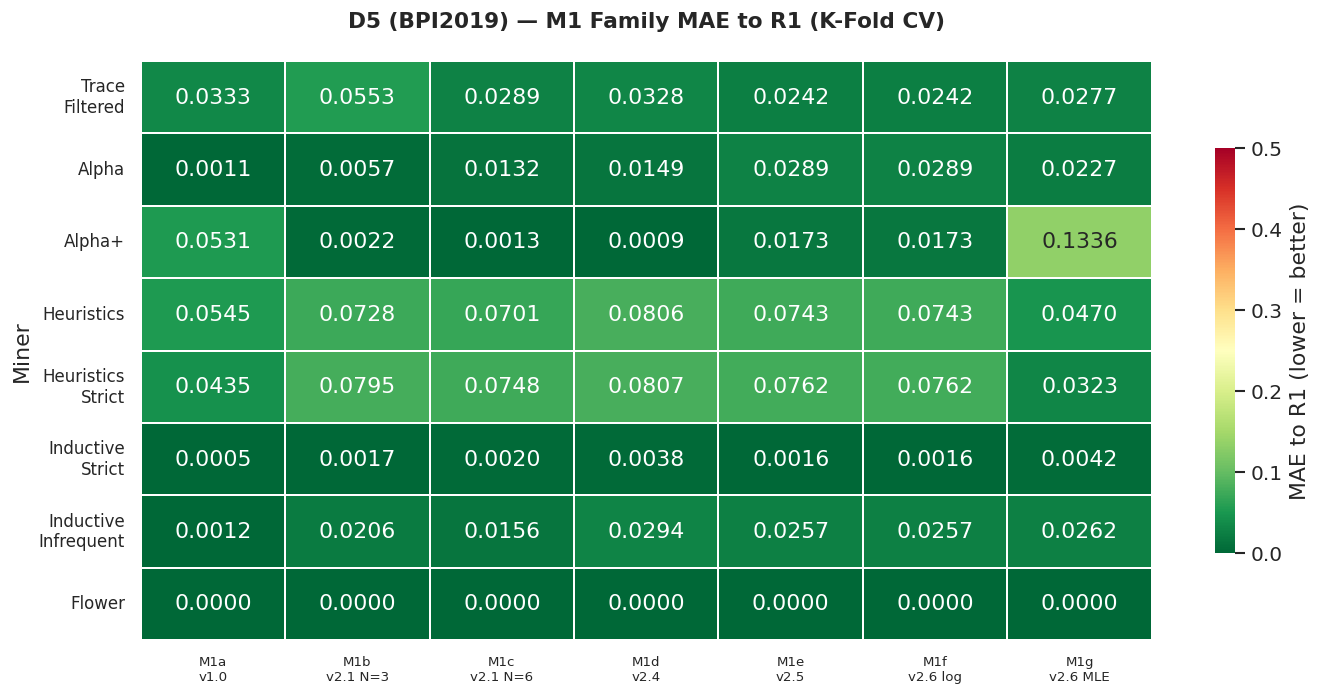

In [27]:
# === Figure 2c: M1 Family MAE to R1 Heatmap ===
METHODS_2C = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g']

r1_vals = pivot_norm['R1']
mae_2c = pd.DataFrame(index=pivot_norm.index, columns=METHODS_2C, dtype=float)
for m in METHODS_2C:
    mae_2c[m] = (pivot_norm[m] - r1_vals).abs()

mae_2c = mae_2c.reindex(index=MINER_ORDER)

# === Handle -1 sentinel (unavailable data) ===
missing_mask_2c = pd.DataFrame(index=mae_2c.index, columns=METHODS_2C, dtype=bool)
for m in METHODS_2C:
    missing_mask_2c[m] = (pivot_norm[m] == -1.0) | (r1_vals == -1.0)

# Clamp missing cells to vmax (0.5) = worst possible MAE
mae_2c = mae_2c.where(~missing_mask_2c, other=0.5)

annot_2c = np.empty_like(mae_2c.values, dtype=object)
for i in range(len(mae_2c.index)):
    for j in range(len(mae_2c.columns)):
        if missing_mask_2c.iloc[i, j]:
            annot_2c[i, j] = "N/A"
        else:
            v = mae_2c.iloc[i, j]
            annot_2c[i, j] = f"{v:.4f}" if not pd.isna(v) else ""

fig, ax = plt.subplots(figsize=(12, 6))
cmap_mae = sns.color_palette("RdYlGn_r", as_cmap=True)

sns.heatmap(
    mae_2c,
    annot=annot_2c,
    fmt='',
    cmap=cmap_mae,
    vmin=0, vmax=0.5,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'MAE to R1 (lower = better)', 'shrink': 0.7},
    ax=ax
)

ax.set_yticklabels([MINER_LABELS.get(m, m) for m in mae_2c.index], rotation=0, fontsize=10)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in mae_2c.columns], rotation=0, fontsize=8)
ax.set_title(f'{DATASET_LABEL} — M1 Family MAE to R1 (K-Fold CV)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Miner')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_fig2c_m1_mae_to_r1.png"), dpi=150, bbox_inches='tight')
mae_2c.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mae_m1_to_r1.csv"))
plt.show()

---
### Figure 2d: Headline & External Methods MAE to R1

M1a (baseline), M1d (v2.4), M1g (headline) vs external methods M2–M7.
M3 normalized via score_m3() to [0,1] for comparability.

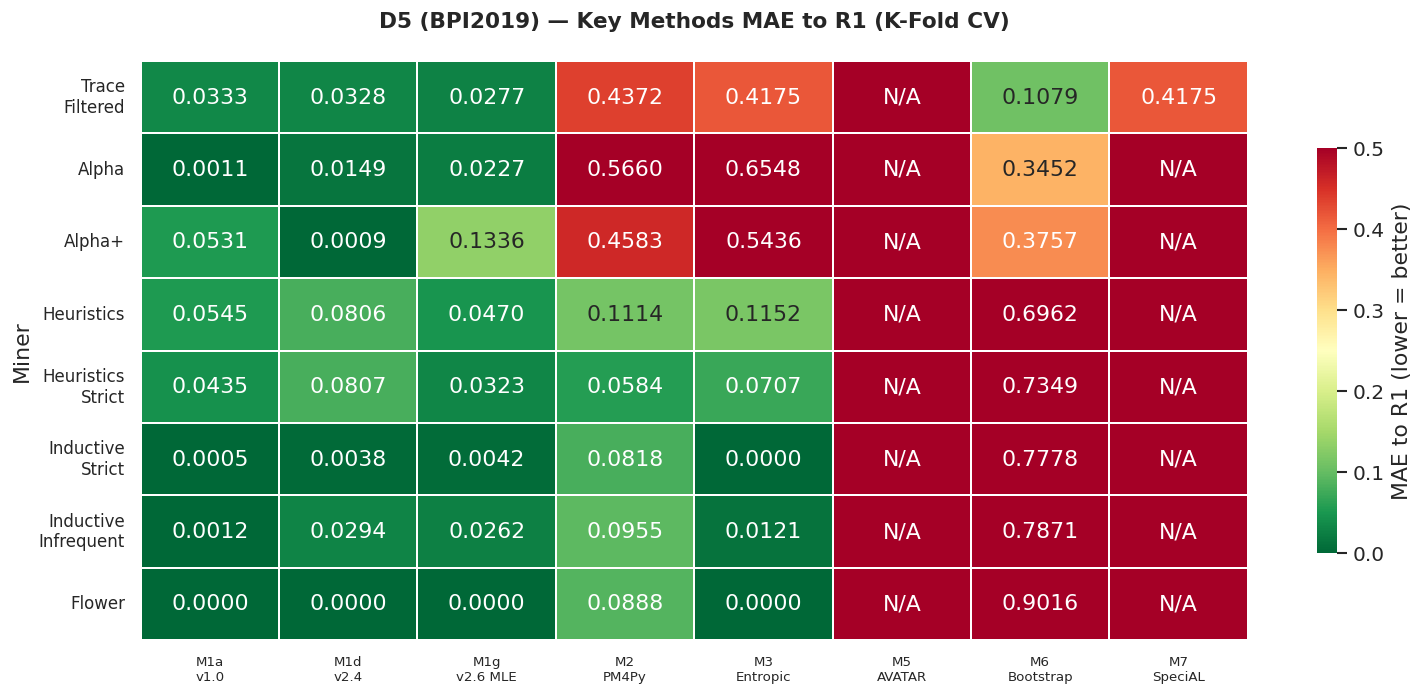

In [28]:
# === Figure 2d: Selected Methods MAE to R1 ===
METHODS_2D = ['M1a', 'M1d', 'M1g', 'M2', 'M3', 'M5', 'M6', 'M7']

r1_vals = pivot_norm['R1']
mae_2d = pd.DataFrame(index=pivot_norm.index, columns=METHODS_2D, dtype=float)
for m in METHODS_2D:
    mae_2d[m] = (pivot_norm[m] - r1_vals).abs()

mae_2d = mae_2d.reindex(index=MINER_ORDER)

# === Handle -1 sentinel (unavailable data) ===
missing_mask_2d = pd.DataFrame(index=mae_2d.index, columns=METHODS_2D, dtype=bool)
for m in METHODS_2D:
    missing_mask_2d[m] = (pivot_norm[m] == -1.0) | (r1_vals == -1.0)

# Clamp missing cells to vmax (0.5) = worst possible MAE
mae_2d = mae_2d.where(~missing_mask_2d, other=0.5)

annot_2d = np.empty_like(mae_2d.values, dtype=object)
for i in range(len(mae_2d.index)):
    for j in range(len(mae_2d.columns)):
        if missing_mask_2d.iloc[i, j]:
            annot_2d[i, j] = "N/A"
        else:
            v = mae_2d.iloc[i, j]
            annot_2d[i, j] = f"{v:.4f}" if not pd.isna(v) else ""

fig, ax = plt.subplots(figsize=(13, 6))
cmap_mae = sns.color_palette("RdYlGn_r", as_cmap=True)

sns.heatmap(
    mae_2d,
    annot=annot_2d,
    fmt='',
    cmap=cmap_mae,
    vmin=0, vmax=0.5,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'MAE to R1 (lower = better)', 'shrink': 0.7},
    ax=ax
)

ax.set_yticklabels([MINER_LABELS.get(m, m) for m in mae_2d.index], rotation=0, fontsize=10)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in mae_2d.columns], rotation=0, fontsize=8)
ax.set_title(f'{DATASET_LABEL} — Key Methods MAE to R1 (K-Fold CV)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Miner')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_fig2d_key_methods_mae_to_r1.png"), dpi=150, bbox_inches='tight')
mae_2d.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mae_key_methods_to_r1.csv"))
plt.show()